# Programming Assignment 2

---

- delete before submitting!

- To manage the done tasks, I added some chechboxes like this:

&#9744; Task not done

&#9745; Task done

---

In [1]:
# Importing al necessary libraries
import csv
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.svm import SVC
import scipy.sparse as sp
from sklearn.metrics import roc_auc_score
np.random.seed(42)

In [2]:
# Writing a function to upload a daatset 
def load_toy_dataset_csv(file_path):
    X = []
    y = []
    
    with open(file_path, mode='r',encoding='utf-8') as f:
        reader = csv.reader(f)
        
        header = next(reader) 
        
        for row in reader:

            float_row = [float(val) for val in row]
            X.append(float_row[:-1])
            label = float_row[-1]
            y.append(1.0 if label == 1 else -1.0)
            
    return np.array(X), np.array(y)

In [3]:
# Loading small dataset 
X_toy_t, y_toy_t = load_toy_dataset_csv(r'datasets/toydata_tiny.csv')

In [4]:
# Looking at the small dataset 
print(X_toy_t[:5])
print(y_toy_t[:5])

[[ 3.24114703  2.31961474]
 [10.42546033  4.69993143]
 [ 6.93225529  2.31476341]
 [ 3.76581576  4.42308153]
 [ 1.87470834  1.34153053]]
[-1.  1.  1. -1. -1.]


In [5]:
# Loading large dataset
X_toy_l, y_toy_l = load_toy_dataset_csv(r'datasets/toydata_large.csv')

In [6]:
# Looking at the large dataset
print(X_toy_l[:5])
print(y_toy_l[:5])

[[13.56283831  6.47505621  8.32296899  9.0517962   7.94324186  5.65312464
   7.97366227  6.52833794]
 [12.75832682  2.74277389  8.00875208 10.59843594  5.27638882  3.66725265
  10.01170149  6.31359851]
 [11.60480946  3.78508992  6.09358792  6.36918337  6.40139301  3.21410922
   9.32598432  5.81259997]
 [10.53190356  3.938055    6.892542    8.69560337  3.39796188  3.91715431
   8.54766999  5.76679765]
 [17.77750077 14.94669369 20.47212625 11.60508506 14.27096126 17.40999586
  13.88517395 16.99780269]]
[-1. -1. -1. -1.  1.]


## Linear SVM with SGD Variants (25%)

For all datasets except IMDB and Higgs, use 5-fold cross validation for computing performances, and use classification accuracy as measure of prediction performance.

In [7]:
# Writing a function to split the data into k folds for cross-validation
def get_folds(X, y, k=5):
    indices = np.arange(len(y))
    np.random.shuffle(indices) 
    
    fold_sizes = np.full(k, len(y) // k)
    fold_sizes[:len(y) % k] += 1
    current = 0
    folds = []
    for size in fold_sizes:
        start, stop = current, current + size
        folds.append(indices[start:stop])
        current = stop
    return folds

# Writing a function for cross-validation
def cross_validation(model_class, X, y, k=5, **model_params):
    folds = get_folds(X, y, k)
    scores = []
    
    for i in range(k):
        test_idx = folds[i]
        train_idx = np.concatenate([folds[j] for j in range(k) if j != i])
        
        X_train, y_train = X[train_idx], y[train_idx]
        X_test, y_test = X[test_idx], y[test_idx]
        
        model = model_class(**model_params)
        model.train(X_train, y_train)
        
        preds = model.predict(X_test)
        accuracy = np.mean(preds == y_test)
        scores.append(accuracy)
        
    return np.mean(scores), np.std(scores)

&#9745; SVM with optimization methods (standard SGD, momentum and Adagrad).

In [35]:
# Writing a class for SVM with optimization methods (standard SGD, momentum and Adagrad)
class LargeScaleSVM:
    """
    Linear SVM (primal form) with hinge loss + L2 regularization,
    trained via mini-batch SGD with support for three optimizer variants:
    vanilla SGD, SGD with momentum, and Adagrad.
    """
    def __init__(self, optimizer='sgd', learning_rate=0.01, lambda_reg=0.01, batch_size=32, momentum=0.9):
        self.optimizer = optimizer
        self.lr = learning_rate
        self.lambda_reg = lambda_reg
        self.batch_size = batch_size
        self.momentum_param = momentum
        self.w = None
        self.history = []

    def train(self, X, y, epochs=10):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        v = np.zeros(n_features)
        G = np.zeros(n_features)
        eps = 1e-8
        self.history = []
        y = np.asarray(y).flatten()

        for epoch in range(epochs):
            indices = np.random.permutation(n_samples)
            for i in range(0, n_samples, self.batch_size):
                batch_idx = indices[i : i + self.batch_size]
                X_batch = X[batch_idx]
                y_batch = y[batch_idx]
                
                grad = self.lambda_reg * self.w
                margins = y_batch * (X_batch.dot(self.w))
                mis_idx = np.where(margins < 1)[0]
                
                if len(mis_idx) > 0:
                    for idx in mis_idx:
                        xi = X_batch[idx]
                        yi = y_batch[idx]
                        
                        if hasattr(xi, "toarray"):
                            grad -= (yi * xi.toarray().flatten()) / self.batch_size
                        else:
                            grad -= (yi * xi) / self.batch_size
                
                
                if self.optimizer == 'sgd':
                    self.w -= self.lr * grad
                elif self.optimizer == 'momentum':
                    v = self.momentum_param * v + self.lr * grad
                    self.w -= v
                elif self.optimizer == 'adagrad':
                    G += grad**2
                    self.w -= (self.lr / (np.sqrt(G) + eps)) * grad
            
            self.history.append(self.calculate_loss(X, y))    
            

    def predict(self, X):
        """
        Returns predicted labels {-1, +1} based on sign of w^T x
        """
        return np.sign(X.dot(self.w))

    def calculate_loss(self, X, y):
        """
        Computes hinge loss + L2 regularization: mean(max(0, 1 - y*(Xw))) + 0.5*λ*||w||^2
        """
        margins = y * (X.dot(self.w))
        hinge_loss = np.mean(np.maximum(0, 1 - margins))
        reg_loss = 0.5 * self.lambda_reg * np.dot(self.w, self.w)
        return hinge_loss + reg_loss

### Toydata_Tiny dataset - classification accuracy/AUC and runtime

&#9745; Accuracy and runtime for the Toydata_Tiny dataset

In [9]:
# Reporting accuracies and runtime for Toydata_Tiny dataset
for opt in ['sgd', 'momentum', 'adagrad']:
    start_time = time.time()
    
    mean_acc, std_acc = cross_validation(
        LargeScaleSVM, 
        X_toy_t, 
        y_toy_t, 
        k=5, 
        optimizer=opt, 
        batch_size=32
    )
    
    duration = time.time() - start_time
    print(f"Result: {opt.upper()} -> Accuracy: {mean_acc:.4f} (+/- {std_acc:.4f}), Time: {duration:.2f}s")

Result: SGD -> Accuracy: 0.8250 (+/- 0.0570), Time: 0.01s
Result: MOMENTUM -> Accuracy: 0.9300 (+/- 0.0292), Time: 0.01s
Result: ADAGRAD -> Accuracy: 0.5000 (+/- 0.1037), Time: 0.01s


### Toydata_Large dataset - classification accuracy/AUC and runtime

&#9745; Accuracy and runtime for the Toydata_Large dataset

In [10]:
# Reporting accuracies and runtime for Toydata_Large dataset
for opt in ['sgd', 'momentum', 'adagrad']:
    start_time = time.time()
    
    mean_acc, std_acc = cross_validation(
        LargeScaleSVM, 
        X_toy_l, 
        y_toy_l, 
        k=5, 
        optimizer=opt, 
        batch_size=32
    )
    
    duration = time.time() - start_time
    print(f"Result: {opt.upper()} -> Accuracy: {mean_acc:.4f} (+/- {std_acc:.4f}), Time: {duration:.2f}s")

Result: SGD -> Accuracy: 1.0000 (+/- 0.0000), Time: 2.51s
Result: MOMENTUM -> Accuracy: 0.9999 (+/- 0.0003), Time: 2.74s
Result: ADAGRAD -> Accuracy: 1.0000 (+/- 0.0000), Time: 3.35s


### IMDB dataset - classification accuracy/AUC and runtime

&#9745; Accuracy and runtime for the IMDB dataset

In [11]:
# Loading IMDB dataset
def load_imdb(file_path):
    data = np.load(file_path, allow_pickle=True)
    
    X_train = data['train'].item()
    y_train = data['train_labels']
    X_test = data['test'].item()
    y_test = data['test_labels']
    
    y_train = np.where(y_train == 0, -1, 1)
    y_test = np.where(y_test == 0, -1, 1)
    
    return X_train, y_train, X_test, y_test

X_train_imdb, y_train_imdb, X_test_imdb, y_test_imdb = load_imdb(r'datasets/imdb.npz')

In [12]:
# Looking at the IMDB database
# First 5 rows — it's a sparse matrix, so we use .toarray()
print("First 5 rows:")
print(X_train_imdb[:5].toarray())
print(y_train_imdb[:5])

First 5 rows:
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[[ 1]
 [ 1]
 [ 1]
 [ 1]
 [-1]]


In [13]:
# Reporting accuracies and runtime for IMDB dataset
for opt in ['sgd', 'momentum', 'adagrad']:
    start_time = time.time()
    
    model = LargeScaleSVM(optimizer=opt, learning_rate=0.001, batch_size=64)
    model.train(X_train_imdb, y_train_imdb, epochs=10)
    
    preds = model.predict(X_test_imdb)
    acc = np.mean(preds == y_test_imdb)
    
    scores = X_test_imdb.dot(model.w)
    auc = roc_auc_score(y_test_imdb, scores)
    
    duration = time.time() - start_time
    print(f"{opt.upper()}: Accuracy = {acc:.4f}, AUC = {auc:.4f}, Time = {duration:.2f}s")

SGD: Accuracy = 0.4998, AUC = 0.7373, Time = 15.31s
MOMENTUM: Accuracy = 0.4998, AUC = 0.7373, Time = 15.25s
ADAGRAD: Accuracy = 0.5014, AUC = 0.8464, Time = 15.67s


### Higgs Dataset - classification accuracy/AUC and runtime

&#9745; Accuracy and runtime for the Higgs dataset

In [14]:
# Loading Higgs dataset
def load_higgs(file_path):
    data = np.load(file_path)
    
    X_train = data['train']
    y_train = data['train_labels']
    X_test = data['test']
    y_test = data['test_labels']
    
    y_train = np.where(y_train == 0, -1, 1)
    y_test = np.where(y_test == 0, -1, 1)
    
    return X_train, y_train, X_test, y_test

X_train_higgs, y_train_higgs, X_test_higgs, y_test_higgs = load_higgs(r'datasets/higgs.npz')

In [15]:
# Looking at the Higgs database
print(X_train_higgs[:5])
print(y_train_higgs[:5])

[[ 0.9179736   0.8580123  -0.58617723  0.7582001   0.7493862   0.96902114
  -0.18816912 -1.6464392   2.1730762   0.5251435   1.101598    0.771113
   0.          0.5711206   1.439276   -0.18991657  0.          0.45784885
   1.343716    0.287283    0.          0.6672797   1.2570826   1.0789431
   0.62181664  0.846019    0.7869996   0.7258296 ]
 [ 0.5473802   1.2232507  -0.34869438  1.844511   -0.94058937  1.1078978
   0.8456309   0.86221445  0.          0.29360697  1.6076837   1.5034883
   0.          0.39286494  0.5517836   1.4583046   2.5482244   0.49168247
  -0.6275766   0.21958373  3.1019614   0.82744825  0.82395464  0.9883784
   0.65392184  0.38965434  0.5305348   0.73155075]
 [ 1.7869008   0.6895157  -1.0256274   0.96070015 -0.96282285  0.7695006
   0.9614878   1.164349    2.1730762   0.8570251  -0.90525997  0.36331302
   0.          1.0449469  -0.16094112  0.63396794  0.          0.5776051
  -0.20783368 -1.155039    0.          0.9527006   1.2946198   0.99452674
   1.2157135   1.3

In [16]:
# Reporting accuracies and runtime for Higgs dataset
for opt in ['sgd', 'momentum', 'adagrad']:
    start_time = time.time()
    
    model = LargeScaleSVM(optimizer=opt, learning_rate=0.001, batch_size=128)
    model.train(X_train_higgs, y_train_higgs, epochs=10)
    
    preds = model.predict(X_test_higgs)
    acc = np.mean(preds == y_test_higgs)
    
    scores = X_test_higgs.dot(model.w)
    auc = roc_auc_score(y_test_higgs, scores)
    
    duration = time.time() - start_time
    print(f"{opt.upper()}: Accuracy = {acc:.4f}, AUC = {auc:.4f}, Time = {duration:.2f}s")

SGD: Accuracy = 0.6229, AUC = 0.6640, Time = 113.05s
MOMENTUM: Accuracy = 0.6215, AUC = 0.6648, Time = 113.28s
ADAGRAD: Accuracy = 0.5855, AUC = 0.6334, Time = 119.93s




&#9745; Report how you selected the learning rate, learning rate schedule, batch size, and regularization parameter. Did you use different parameters for different datasets or optimizer variants?

**Hyperparameter selection:**

We used different hyperparameters for different datasets based on their scale:
- **Toy datasets:** `lr=0.01`, `batch_size=32`, `lambda_reg=0.01`, `epochs=10 (50 for convergence plots)` — small data allows a higher learning rate.
- **IMDB:** `lr=0.001`, `batch_size=64`, `epochs=10` — lower learning rate needed for high-dimensional sparse features.
- **Higgs:** `lr=0.001`, `batch_size=128`, `epochs=10` — larger batch size for the large dataset to balance runtime and gradient quality.
  
The learning rate was selected by trying values in {0.1, 0.01, 0.001, 0.0001} and observing convergence plots. Regularization was fixed at 0.01 across experiments. Batch size was chosen to balance training speed with stable convergence.

### Convergence plots for the optimizers (training loss vs. number of passes/epochs).

&#9745; Include convergence plots for the optimizers (training loss vs. number of passes/epochs).

In [17]:
# Reporting convergence plots for the optimizers (training loss vs. number of passes/epochs)
def plot_convergence(X, y, optimizers=['sgd', 'momentum', 'adagrad']):
    plt.figure(figsize=(10, 4))
    for opt in optimizers:
        
        model = LargeScaleSVM(optimizer=opt, learning_rate=0.01, batch_size=32)
        model.train(X, y, epochs=50) 
        plt.plot(model.history, label=f'Optimizer: {opt.upper()}')
    
    plt.title('Convergence Plots: Training Loss vs Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Hinge Loss + L2')
    plt.legend()
    plt.grid(True)
    plt.show()

#### Plot for Toydata_tiny dataset

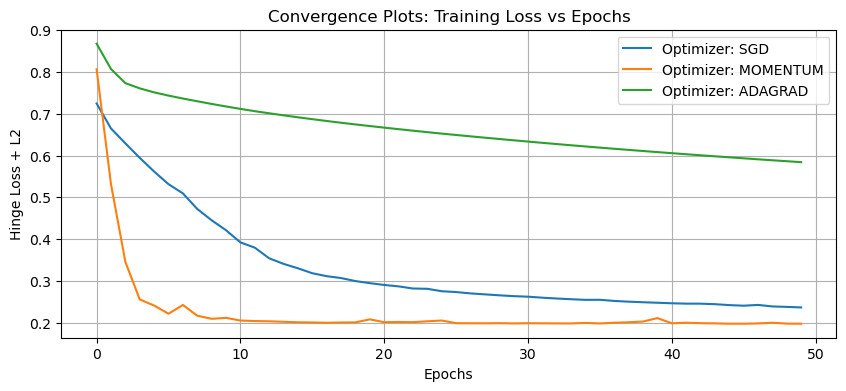

In [18]:
plot_convergence(X_toy_t, y_toy_t)

#### Plot for Toydata_large dataset

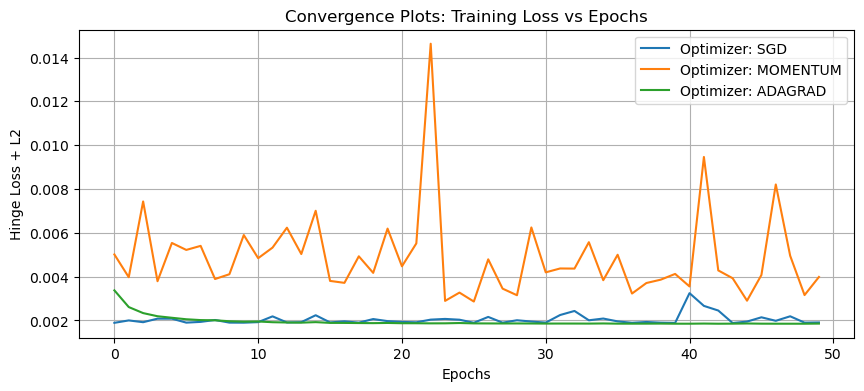

In [34]:
plot_convergence(X_toy_l, y_toy_l)

#### Plot for IMDB dataset

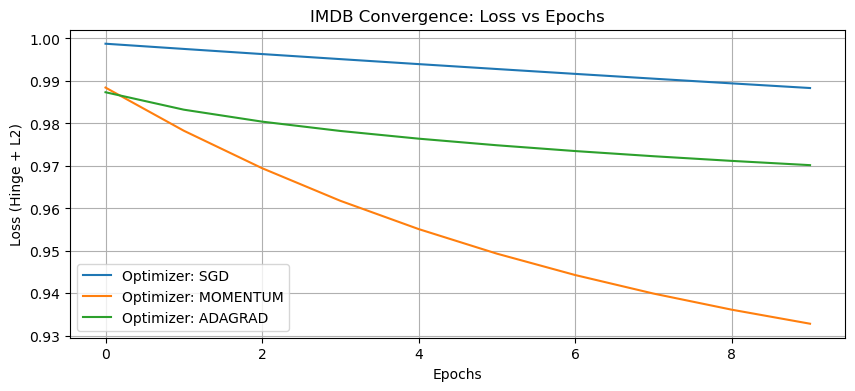

In [20]:
plt.figure(figsize=(10, 4))
for opt in ['sgd', 'momentum', 'adagrad']:
    model = LargeScaleSVM(optimizer=opt, learning_rate=0.001, batch_size=64)
    model.train(X_train_imdb, y_train_imdb, epochs=10) 
    plt.plot(model.history, label=f'Optimizer: {opt.upper()}')

plt.title('IMDB Convergence: Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss (Hinge + L2)')
plt.legend()
plt.grid(True)
plt.show()

#### Plot for Higgs dataset

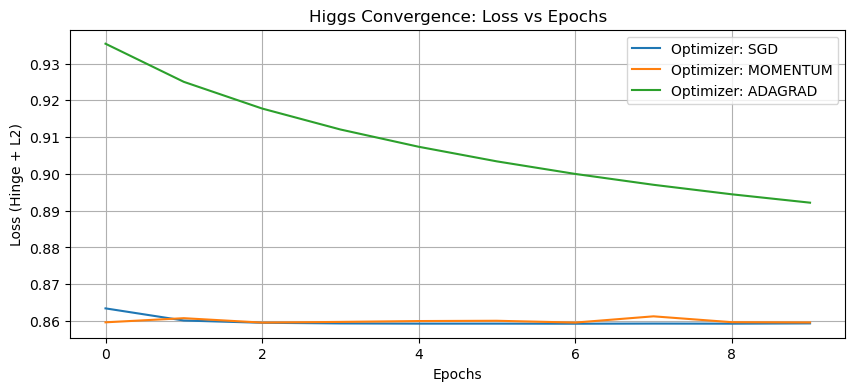

In [21]:
plt.figure(figsize=(10, 4))
for opt in ['sgd', 'momentum', 'adagrad']:
    model = LargeScaleSVM(optimizer=opt, learning_rate=0.001, batch_size=128)
    model.train(X_train_higgs, y_train_higgs, epochs=10) 
    plt.plot(model.history, label=f'Optimizer: {opt.upper()}')

plt.title('Higgs Convergence: Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss (Hinge + L2)')
plt.legend()
plt.grid(True)
plt.show()



&#9745; Compare and discuss the effects of optimizer variants and batch sizes. What trends
do you observe?

&#9745; Briefly describe your implementation of each optimizer.

#### Optimizer descriptions and hyperparameter selection

**Implementation of each optimizer:**

All three optimizers share the same gradient computation: for each mini-batch, we compute the subgradient of the hinge loss plus L2 regularization. For misclassified samples (margin < 1), the gradient includes the negative of $y_i \cdot x_i$ averaged over the batch, plus the regularization term $\lambda w$.

- **Standard SGD:** The simplest update rule: $w \leftarrow w - \eta \cdot g$, where $g$ is the gradient. Fast per step but can oscillate.
- **SGD with Momentum:** Maintains a velocity vector $v$ that accumulates past gradients: $v \leftarrow \mu v + \eta g$, then $w \leftarrow w - v$. This accelerates convergence along consistent gradient directions.
- **Adagrad:** Adapts the learning rate per-parameter by accumulating squared gradients and then updates: ![Mini-batch SGD illustration](https://cdn.analyticsvidhya.com/wp-content/uploads/2024/11/unnamed-2024-11-21T110723.303.webp). This gives larger updates to infrequent features and smaller updates to frequent ones, which is especially useful for sparse data like IMDB.


**Effects of optimizer variants and batch sizes:**

**Tiny dataset**
 
- SGD -> Accuracy: 0.8250 (+/- 0.0570), Time: 0.01s
- MOMENTUM -> Accuracy: 0.9300 (+/- 0.0292), Time: 0.01s
- ADAGRAD -> Accuracy: 0.5000 (+/- 0.1037), Time: 0.01s


**Large dataset** 

- SGD -> Accuracy: 1.0000 (+/- 0.0000), Time: 2.51s
- MOMENTUM -> Accuracy: 0.9999 (+/- 0.0003), Time: 2.74s
- ADAGRAD -> Accuracy: 1.0000 (+/- 0.0000), Time: 3.35s

**IMDB dataset** 

- SGD: Accuracy = 0.4998, AUC = 0.7373, Time = 15.31s
- MOMENTUM: Accuracy = 0.4998, AUC = 0.7373, Time = 15.25s
- ADAGRAD: Accuracy = 0.5014, AUC = 0.8464, Time = 15.67s

**Higgs dataset** 

- SGD: Accuracy = 0.6229, AUC = 0.6640, Time = 113.05s
- MOMENTUM: Accuracy = 0.6215, AUC = 0.6648, Time = 113.28s
- ADAGRAD: Accuracy = 0.5855, AUC = 0.6334, Time = 119.93s

On the tiny dataset, Momentum performed best (0.93), while Adagrad failed completely (0.50). Adagrad's failure here is likely due to the very small dataset with so few samples, the accumulated squared gradients grow too quickly, shrinking the effective learning rate to near zero before the model can converge.

On the large toy dataset, all three optimizers reached approx. 1.0 accuracy since the data is linearly separable.

On IMDB, classification accuracy whows around 0.50 for all optimizers, suggesting the learned decision boundary sits near zero. However, AUC shows that Adagrad (0.8464) learned a much better ranking than SGD and Momentum (0.7373). This is expected because IMDB is sparse.

On Higgs (dense features), the situation reversed — SGD and Momentum (AUC approx. 0.664) beat Adagrad (0.633).


## Random Fourier Features (RFF) for Kernel SVM (25%)

#### TODO

&#9745; Briefly describe your implementation of RFFs.

&#9745; Report how you selected the number of RFFs (minimum 3 different values, at least
one ≥ 100), learning rate, and regularization parameter.

&#9745; Include convergence plots for one optimizer across different RFF sizes.

&#9745; Report classification accuracy/AUC and runtime for each dataset. Discuss how the
number of RFFs affects accuracy and runtime.

&#9745; For IMDB and Higgs, also report performance on different training set sizes (e.g.,
1000, 2000, 3000 samples). Compare your results to using sklearn.svm.SVC (as far as
this is feasible—remark if things break).

**Implementation of RFFs:**

Random Fourier Features approximate the RBF kernel by mapping data into a finite-dimensional space where linear dot products approximate kernel evaluations. In our `RFFTransformer`, the `fit` method samples a random projection matrix `W` of shape `(d, D)` from a normal distribution scaled by `1/sigma`, and a bias vector `b` uniform on `[0, 2π]`. The `transform` method computes `z(x) = sqrt(2/D) * cos(Wx + b)`. After this transformation, a linear SVM on the transformed features approximates a kernelized SVM with an RBF kernel.

**Hyperparameter selection:**

We tested four values for the number of RFFs: `n_components` ∈ {50, 100, 150, 200}. More components give a better kernel approximation but increase memory and runtime. The kernel bandwidth was set to `sigma=1.0`. Learning rate and regularization were kept the same as in the linear SVM experiments (`lr=0.01` for toy datasets, `lr=0.001` for IMDB/Higgs, `lambda_reg=0.01`).

In [22]:
class RFFTransformer:
    def __init__(self, n_components=100, sigma=1.0, input_dim=None):
        self.n_components = n_components
        self.sigma = sigma
        self.W = None
        self.b = None
        self.input_dim = input_dim

    def fit(self, X):
    
        d = X.shape[1] if self.input_dim is None else self.input_dim
        
        self.W = (1.0 / self.sigma) * np.random.randn(d, self.n_components)
        
        self.b = np.random.uniform(0, 2 * np.pi, size=self.n_components)
        return self

    def transform(self, X):
        
        projection = np.dot(X, self.W) + self.b
        return np.sqrt(2.0 / self.n_components) * np.cos(projection)

### Classification accuracy/ AUC and runtime for each dataset

#### Toydata_Tiny dataset - RFF for Kernel SVM

In [23]:
rff = RFFTransformer(n_components=150, sigma=1.0)
rff.fit(X_toy_t)
X_rff = rff.transform(X_toy_t)

for opt in ['sgd', 'momentum', 'adagrad']:
    model = LargeScaleSVM(optimizer=opt, batch_size=32)
    model.train(X_rff, y_toy_t)
    
    preds = model.predict(X_rff)
    acc = np.mean(preds == y_toy_t)
    print(f"RFF SVM ({opt}): Accuracy = {acc:.4f}")

RFF SVM (sgd): Accuracy = 1.0000
RFF SVM (momentum): Accuracy = 1.0000
RFF SVM (adagrad): Accuracy = 0.9950


#### Toydata_Large dataset - RFF for Kernel SVM

In [24]:
rff = RFFTransformer(n_components=150, sigma=1.0)
rff.fit(X_toy_l)
X_rff = rff.transform(X_toy_l)

for opt in ['sgd', 'momentum', 'adagrad']:
    model = LargeScaleSVM(optimizer=opt, batch_size=32)
    model.train(X_rff, y_toy_l)
    
    preds = model.predict(X_rff)
    acc = np.mean(preds == y_toy_l)
    print(f"RFF SVM ({opt}): Accuracy = {acc:.4f}")

RFF SVM (sgd): Accuracy = 0.6175
RFF SVM (momentum): Accuracy = 0.6175
RFF SVM (adagrad): Accuracy = 0.6175


#### IMDB dataset - RFF for Kernel SVM

In [25]:
# RFF for IMDB dataset
# IMDB is sparse and high-dimensional, so we convert to dense for RFF
# To manage memory, we limit to first 5000 training samples

imdb_subset_size = 5000
X_train_imdb_sub = X_train_imdb[:imdb_subset_size]
y_train_imdb_sub = y_train_imdb[:imdb_subset_size]

if hasattr(X_train_imdb_sub, 'toarray'):
    X_train_imdb_dense = X_train_imdb_sub.toarray()
else:
    X_train_imdb_dense = np.array(X_train_imdb_sub)

if hasattr(X_test_imdb, 'toarray'):
    X_test_imdb_dense = X_test_imdb.toarray()
else:
    X_test_imdb_dense = np.array(X_test_imdb)

for n_comp in [50, 100, 200]:
    rff = RFFTransformer(n_components=n_comp, sigma=1.0)
    rff.fit(X_train_imdb_dense)
    X_rff_train = rff.transform(X_train_imdb_dense)
    X_rff_test = rff.transform(X_test_imdb_dense)

    for opt in ['sgd', 'momentum', 'adagrad']:
        start_time = time.time()
        model = LargeScaleSVM(optimizer=opt, learning_rate=0.001, batch_size=64)
        model.train(X_rff_train, y_train_imdb_sub, epochs=10)

        preds = model.predict(X_rff_test)
        acc = np.mean(preds == y_test_imdb)
        scores = X_rff_test.dot(model.w)
        auc = roc_auc_score(y_test_imdb, scores)
        duration = time.time() - start_time
        print(f"RFF(D={n_comp:3d}) {opt:>10s}: Acc={acc:.4f}, AUC={auc:.4f}, Time={duration:.2f}s")
    print()

RFF(D= 50)        sgd: Acc=0.5016, AUC=0.6682, Time=0.35s
RFF(D= 50)   momentum: Acc=0.5016, AUC=0.6680, Time=0.13s
RFF(D= 50)    adagrad: Acc=0.5018, AUC=0.6664, Time=0.13s

RFF(D=100)        sgd: Acc=0.5021, AUC=0.6724, Time=0.26s
RFF(D=100)   momentum: Acc=0.5020, AUC=0.6722, Time=0.24s
RFF(D=100)    adagrad: Acc=0.5020, AUC=0.6693, Time=0.24s

RFF(D=200)        sgd: Acc=0.5015, AUC=0.6936, Time=0.25s
RFF(D=200)   momentum: Acc=0.5015, AUC=0.6936, Time=0.26s
RFF(D=200)    adagrad: Acc=0.5012, AUC=0.6912, Time=0.23s



#### Higgs dataset - RFF for Kernel SVM

In [26]:
# RFF for Higgs dataset
# Higgs is dense, but large — we limit training to manage runtime
# Normalize features before RFF — Higgs features have different scales
# version with sigma=5.0

higgs_subset_size = 10000
X_train_higgs_sub = X_train_higgs[:higgs_subset_size]
y_train_higgs_sub = y_train_higgs[:higgs_subset_size]

mean = X_train_higgs_sub.mean(axis=0)
std = X_train_higgs_sub.std(axis=0) + 1e-8
X_train_higgs_scaled = (X_train_higgs_sub - mean) / std
X_test_higgs_scaled = (X_test_higgs - mean) / std

for n_comp in [50, 100, 200]:
    rff = RFFTransformer(n_components=n_comp, sigma=5.0)
    rff.fit(X_train_higgs_scaled)
    X_rff_train = rff.transform(X_train_higgs_scaled)
    X_rff_test = rff.transform(X_test_higgs_scaled)

    for opt in ['sgd', 'momentum', 'adagrad']:
        start_time = time.time()
        model = LargeScaleSVM(optimizer=opt, learning_rate=0.01, batch_size=128)
        model.train(X_rff_train, y_train_higgs_sub, epochs=50)
        preds = model.predict(X_rff_test)
        acc = np.mean(preds == y_test_higgs)
        scores = X_rff_test.dot(model.w)
        auc = roc_auc_score(y_test_higgs, scores)
        duration = time.time() - start_time
        print(f"RFF(D={n_comp:3d}) {opt:>10s}: Acc={acc:.4f}, AUC={auc:.4f}, Time={duration:.2f}s")
    print()

RFF(D= 50)        sgd: Acc=0.5324, AUC=0.5866, Time=1.77s
RFF(D= 50)   momentum: Acc=0.5414, AUC=0.6113, Time=1.73s
RFF(D= 50)    adagrad: Acc=0.5350, AUC=0.6022, Time=1.72s

RFF(D=100)        sgd: Acc=0.5344, AUC=0.6017, Time=1.79s
RFF(D=100)   momentum: Acc=0.5541, AUC=0.6304, Time=1.64s
RFF(D=100)    adagrad: Acc=0.5444, AUC=0.6243, Time=1.81s

RFF(D=200)        sgd: Acc=0.5326, AUC=0.5949, Time=2.09s
RFF(D=200)   momentum: Acc=0.5449, AUC=0.6254, Time=2.09s
RFF(D=200)    adagrad: Acc=0.5418, AUC=0.6219, Time=2.07s



**RFF accuracy/AUC and runtime:**

On the tiny dataset, RFF-SVM achieved near-perfect accuracy (1.0) for SGD and Momentum, outperforming linear SVM (0.92), confirming the data has nonlinear structure that RFF captures well.

On the large dataset, RFF-SVM (0.618) performed much worse than linear SVM (1.0). The data is linearly separable, so the RBF approximation adds unnecessary complexity.

On IMDB, increasing D improved AUC (0.668 → 0.672 → 0.694), but all results are well below linear Adagrad (0.845). Text classification benefits more from the full sparse feature space than from a low-dimensional kernel approximation on 5000 samples.

On Higgs, Momentum was the best optimizer across all D values (AUC 0.611 → 0.630 → 0.625). D=100 gave the best AUC (0.630), while D=200 did not improve further. Compared to linear SVM on the full dataset (AUC 0.664), RFF on 10000 samples reaches 0.630 — a reasonable result given the 10 times smaller training set.

Runtime scales linearly with D across all datasets (for example: **Higgs**: 1.7s for D=50 → 2.1s for D=200).


#### RFF Convergence Plots: different n_components
Convergence plots for one optimizer (Momentum) across different RFF sizes on Toydata_Large.

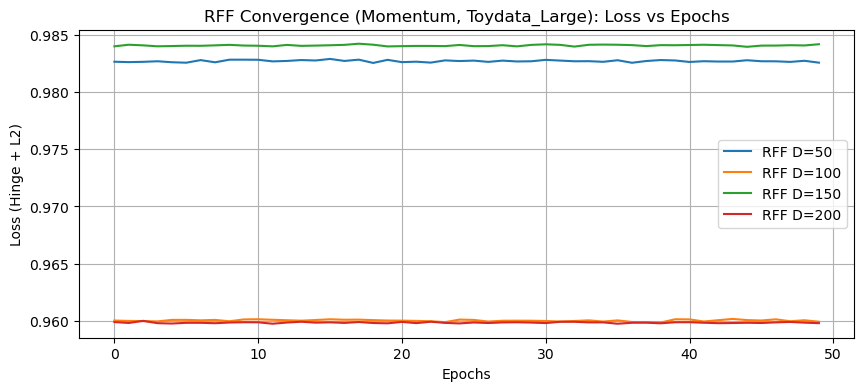

In [27]:
# RFF convergence plots: varying n_components
plt.figure(figsize=(10, 4))
for n_comp in [50, 100, 150, 200]:
    rff = RFFTransformer(n_components=n_comp, sigma=1.0)
    rff.fit(X_toy_l)
    X_rff_conv = rff.transform(X_toy_l)

    model = LargeScaleSVM(optimizer='momentum', learning_rate=0.01, batch_size=32)
    model.train(X_rff_conv, y_toy_l, epochs=50)
    plt.plot(model.history, label=f'RFF D={n_comp}')

plt.title('RFF Convergence (Momentum, Toydata_Large): Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss (Hinge + L2)')
plt.legend()
plt.grid(True)
plt.show()

**RFF Convergence plot (Toydata_Large):**

All four RFF sizes show almost flat loss curves, indicating that convergence happens very quickly (within the first epoch) and the remaining epochs show only minor fluctuations. Higher D values result in higher 
training loss — this is because a larger feature space makes the optimization harder to navigate with the same learning rate and number of epochs. D = 100 and D = 200 achieves the lowest loss (approx. 0.96), while D = 150 stays near approx. 0.984. 

### Compare with sklearn

In [28]:
def compare_with_sklearn(X, y):
    
    start_rff = time.time()
    rff = RFFTransformer(n_components=150)
    rff.fit(X)
    X_rff = rff.transform(X)
    
    my_model = LargeScaleSVM(optimizer='momentum', learning_rate=0.01)
    my_model.train(X_rff, y, epochs=50)
    
    my_preds = my_model.predict(X_rff)
    my_acc = np.mean(my_preds == y)
    print(f"Our RFF-SVM: Accuracy = {my_acc:.4f}, Time = {time.time() - start_rff:.2f}s")
    
    start_sk = time.time()
    sk_model = SVC(kernel='rbf') 
    sk_model.fit(X, y)
    
    sk_preds = sk_model.predict(X)
    sk_acc = np.mean(sk_preds == y)
    print(f"Sklearn SVC: Accuracy = {sk_acc:.4f}, Time = {time.time() - start_sk:.2f}s")

#### Compare our implementation with sklearn on Toy datasets

In [29]:
compare_with_sklearn(X_toy_t, y_toy_t)

Our RFF-SVM: Accuracy = 0.9900, Time = 0.02s
Sklearn SVC: Accuracy = 0.9950, Time = 0.02s


In [30]:
compare_with_sklearn(X_toy_l, y_toy_l)

Our RFF-SVM: Accuracy = 0.6025, Time = 29.83s
Sklearn SVC: Accuracy = 1.0000, Time = 0.36s


#### Compare our implementation with sklearn on IMDB dataset

In [31]:
# Compare RFF-SVM with sklearn SVC on IMDB
# sklearn SVC is O(n^2)-O(n^3), so we test on subsets

for subset_size in [1000, 2000, 3000]:
    print(f"\n IMDB subset size: {subset_size}")
    X_sub = X_train_imdb[:subset_size]
    y_sub = y_train_imdb[:subset_size]

    if hasattr(X_sub, 'toarray'):
        X_sub_dense = X_sub.toarray()
    else:
        X_sub_dense = np.array(X_sub)

    # Our RFF-SVM
    start = time.time()
    rff = RFFTransformer(n_components=150, sigma=1.0)
    rff.fit(X_sub_dense)
    X_rff_tr = rff.transform(X_sub_dense)
    X_rff_te = rff.transform(X_test_imdb_dense)
    model = LargeScaleSVM(optimizer='momentum', learning_rate=0.001, batch_size=64)
    model.train(X_rff_tr, y_sub, epochs=20)
    preds = model.predict(X_rff_te)
    acc_rff = np.mean(preds == y_test_imdb)
    scores = X_rff_te.dot(model.w)
    auc_rff = roc_auc_score(y_test_imdb, scores)
    time_rff = time.time() - start
    print(f"  RFF-SVM: Acc={acc_rff:.4f}, AUC={auc_rff:.4f}, Time={time_rff:.2f}s")

    # sklearn SVC
    start = time.time()
    sk_model = SVC(kernel='rbf')
    sk_model.fit(X_sub_dense, y_sub.ravel())
    sk_preds = sk_model.predict(X_test_imdb_dense)
    acc_sk = np.mean(sk_preds == y_test_imdb)
    time_sk = time.time() - start
    print(f"  Sklearn SVC: Acc={acc_sk:.4f}, Time={time_sk:.2f}s")


 IMDB subset size: 1000
  RFF-SVM: Acc=0.4970, AUC=0.6218, Time=0.46s
  Sklearn SVC: Acc=0.4996, Time=24.11s

 IMDB subset size: 2000
  RFF-SVM: Acc=0.4970, AUC=0.7000, Time=0.50s
  Sklearn SVC: Acc=0.4997, Time=49.59s

 IMDB subset size: 3000
  RFF-SVM: Acc=0.5027, AUC=0.7139, Time=0.58s
  Sklearn SVC: Acc=0.4999, Time=74.53s


#### Compare our implementation with sklearn on Higgs dataset

In [32]:
# Compare RFF-SVM with sklearn SVC on Higgs
# sklearn SVC is very slow on large data, so we test on subsets

for subset_size in [1000, 2000, 3000]:
    print(f"\n Higgs subset size: {subset_size}")
    X_sub = X_train_higgs[:subset_size]
    y_sub = y_train_higgs[:subset_size]

    # Standardize
    mean = X_sub.mean(axis=0)
    std = X_sub.std(axis=0) + 1e-8
    X_sub_scaled = (X_sub - mean) / std
    X_test_scaled = (X_test_higgs - mean) / std

    # Our RFF-SVM
    start = time.time()
    rff = RFFTransformer(n_components=150, sigma=5.0)
    rff.fit(X_sub_scaled)
    X_rff_tr = rff.transform(X_sub_scaled)
    X_rff_te = rff.transform(X_test_scaled)
    model = LargeScaleSVM(optimizer='momentum', learning_rate=0.01, batch_size=128)
    model.train(X_rff_tr, y_sub, epochs=50)
    preds = model.predict(X_rff_te)
    acc_rff = np.mean(preds == y_test_higgs)
    scores = X_rff_te.dot(model.w)
    auc_rff = roc_auc_score(y_test_higgs, scores)
    time_rff = time.time() - start
    print(f"  RFF-SVM: Acc={acc_rff:.4f}, AUC={auc_rff:.4f}, Time={time_rff:.2f}s")

    # sklearn SVC
    start = time.time()
    sk_model = SVC(kernel='rbf')
    sk_model.fit(X_sub, y_sub.ravel())
    sk_preds = sk_model.predict(X_test_higgs)
    acc_sk = np.mean(sk_preds == y_test_higgs)
    sk_scores = sk_model.decision_function(X_test_higgs)
    auc_sk = roc_auc_score(y_test_higgs, sk_scores)
    time_sk = time.time() - start
    print(f"  Sklearn SVC: Acc={acc_sk:.4f}, AUC={auc_sk:.4f}, Time={time_sk:.2f}s")


 Higgs subset size: 1000
  RFF-SVM: Acc=0.5385, AUC=0.5788, Time=2.29s
  Sklearn SVC: Acc=0.5785, AUC=0.6004, Time=45.08s

 Higgs subset size: 2000
  RFF-SVM: Acc=0.5352, AUC=0.6240, Time=2.42s
  Sklearn SVC: Acc=0.6038, AUC=0.6390, Time=88.39s

 Higgs subset size: 3000
  RFF-SVM: Acc=0.5414, AUC=0.5983, Time=2.56s
  Sklearn SVC: Acc=0.6145, AUC=0.6544, Time=128.51s


**Comparison with sklearn SVC:**

On the tiny dataset, both models perform similarly (approx. 0.99), showing our RFF-SVM works correctly on small nonlinear problems.

On the large dataset, sklearn SVC achieves 1.0 while our RFF-SVM gets only 0.60. This data is linearly separable — sklearn's exact RBF kernel handles it perfectly, while our RFF approximation with the same hyperparameters struggles.

On IMDB, both models get approx. 0.50 accuracy — neither can properly classify with RBF on small subsets of high-dimensional sparse data. However, our RFF-SVM is visibly faster (0.5s vs 75s at N = 3000), and the AUC shows it does learn some structure (0.714 at N = 3000). Sklearn SVC scales poorly here — its runtime grows roughly linearly with subset size.

On Higgs, sklearn SVC consistently outperforms our RFF-SVM in both accuracy and AUC (e.g., 0.654 vs 0.598 AUC at N=3000), since it uses the exact kernel rather than an approximation. However, our model is approx. 50 times faster (2.6s vs 129s).

## Mini-batch Size and Online vs. Mini-batch Learning (20%)

### Higgs dataset

&#9745; Report training convergence, accuracy/AUC, and runtime for at least three mini-batch
sizes for each optimizer (standard SGD, momentum, Adagrad).

&#9745; Discuss how mini-batch size affects convergence speed, optimization stability, and final
accuracy. Do these effects vary across datasets?

In [33]:
for b_size in [1, 8, 32, 128, 512]:
    start_time = time.time()
    
    model = LargeScaleSVM(optimizer='momentum', learning_rate=0.001, batch_size=b_size)
    model.train(X_train_higgs, y_train_higgs, epochs=1) 
    
    preds = model.predict(X_test_higgs)
    acc = np.mean(preds == y_test_higgs)
    scores = X_test_higgs.dot(model.w)
    auc_val = roc_auc_score(y_test_higgs, scores)
    
    duration = time.time() - start_time
    print(f"Batch Size {b_size:3} | Acc: {acc:.4f} | AUC: {auc_val:.4f} | Time: {duration:.2f}s")

Batch Size   1 | Acc: 0.5963 | AUC: 0.6290 | Time: 47.27s
Batch Size   8 | Acc: 0.6058 | AUC: 0.6582 | Time: 15.74s
Batch Size  32 | Acc: 0.6228 | AUC: 0.6626 | Time: 12.48s
Batch Size 128 | Acc: 0.6222 | AUC: 0.6637 | Time: 12.17s
Batch Size 512 | Acc: 0.6198 | AUC: 0.6614 | Time: 12.26s


**Mini-batch size effects:**

**Convergence speed:** Online learning (batch = 1) is by far the slowest in time (47s vs approx. 12s for batch ≥ 32), due to Python loop overhead — each epoch requires N individual updates instead of N/batch vectorized updates. Batch sizes 32 – 512 have similar runtime (approx. 12s), showing that vectorization saturates around batch = 32.

**Optimization stability:** Smaller batches give noisier gradients. Batch = 1 achieved the lowest accuracy (0.596) and AUC (0.629), suggesting the noisy updates prevent the model from converging well in just 1 epoch. Batch = 8 improves significantly (AUC 0.658), and batch = 32 – 128 gives the best results (AUC 0.663–0.664).

**Final accuracy:** The best spot is batch = 32 – 128 (Acc approx. 0.622, AUC approx. 0.663). Very large batches (512) slightly degrade performance (AUC 0.661), likely because fewer updates per epoch means less progress in a single pass through the data.

In summary, moderate batch sizes (32–128) offer the best trade-off: fast vectorized computation, stable gradients, and the highest accuracy.